**GATE Retention height**

*Sensitivity analysis*

  Design water level:       h_d     = NAP +6.83 m
  Significant wave height:  H_s,d   = 3.61 m
  Oblique wave factor:      γ_β     = 1.0
  Nose structure factor:    γ_η     = 1.0
  Sill level:               z_sill  = NAP -17.0 m
  Gravitational accel.:     g       = 9.81 m/s²

    q [m³/s/m] |  h_kr [m] |  h_r [m NAP] |  h_gate [m]
  ----------------------------------------------------
         0.001 |      9.55 |       +16.38 |       33.38
         0.010 |      6.78 |       +13.61 |       30.61
         0.100 |      4.01 |       +10.84 |       27.84
         0.200 |      3.17 |       +10.00 |       27.00
         0.500 |      2.07 |        +8.90 |       25.90
         1.000 |      1.24 |        +8.07 |       25.07
         2.000 |      0.40 |        +7.23 |       24.23
         5.000 |     -0.70 |        +6.13 |       23.13
        10.000 |     -1.53 |        +5.30 |       22.30


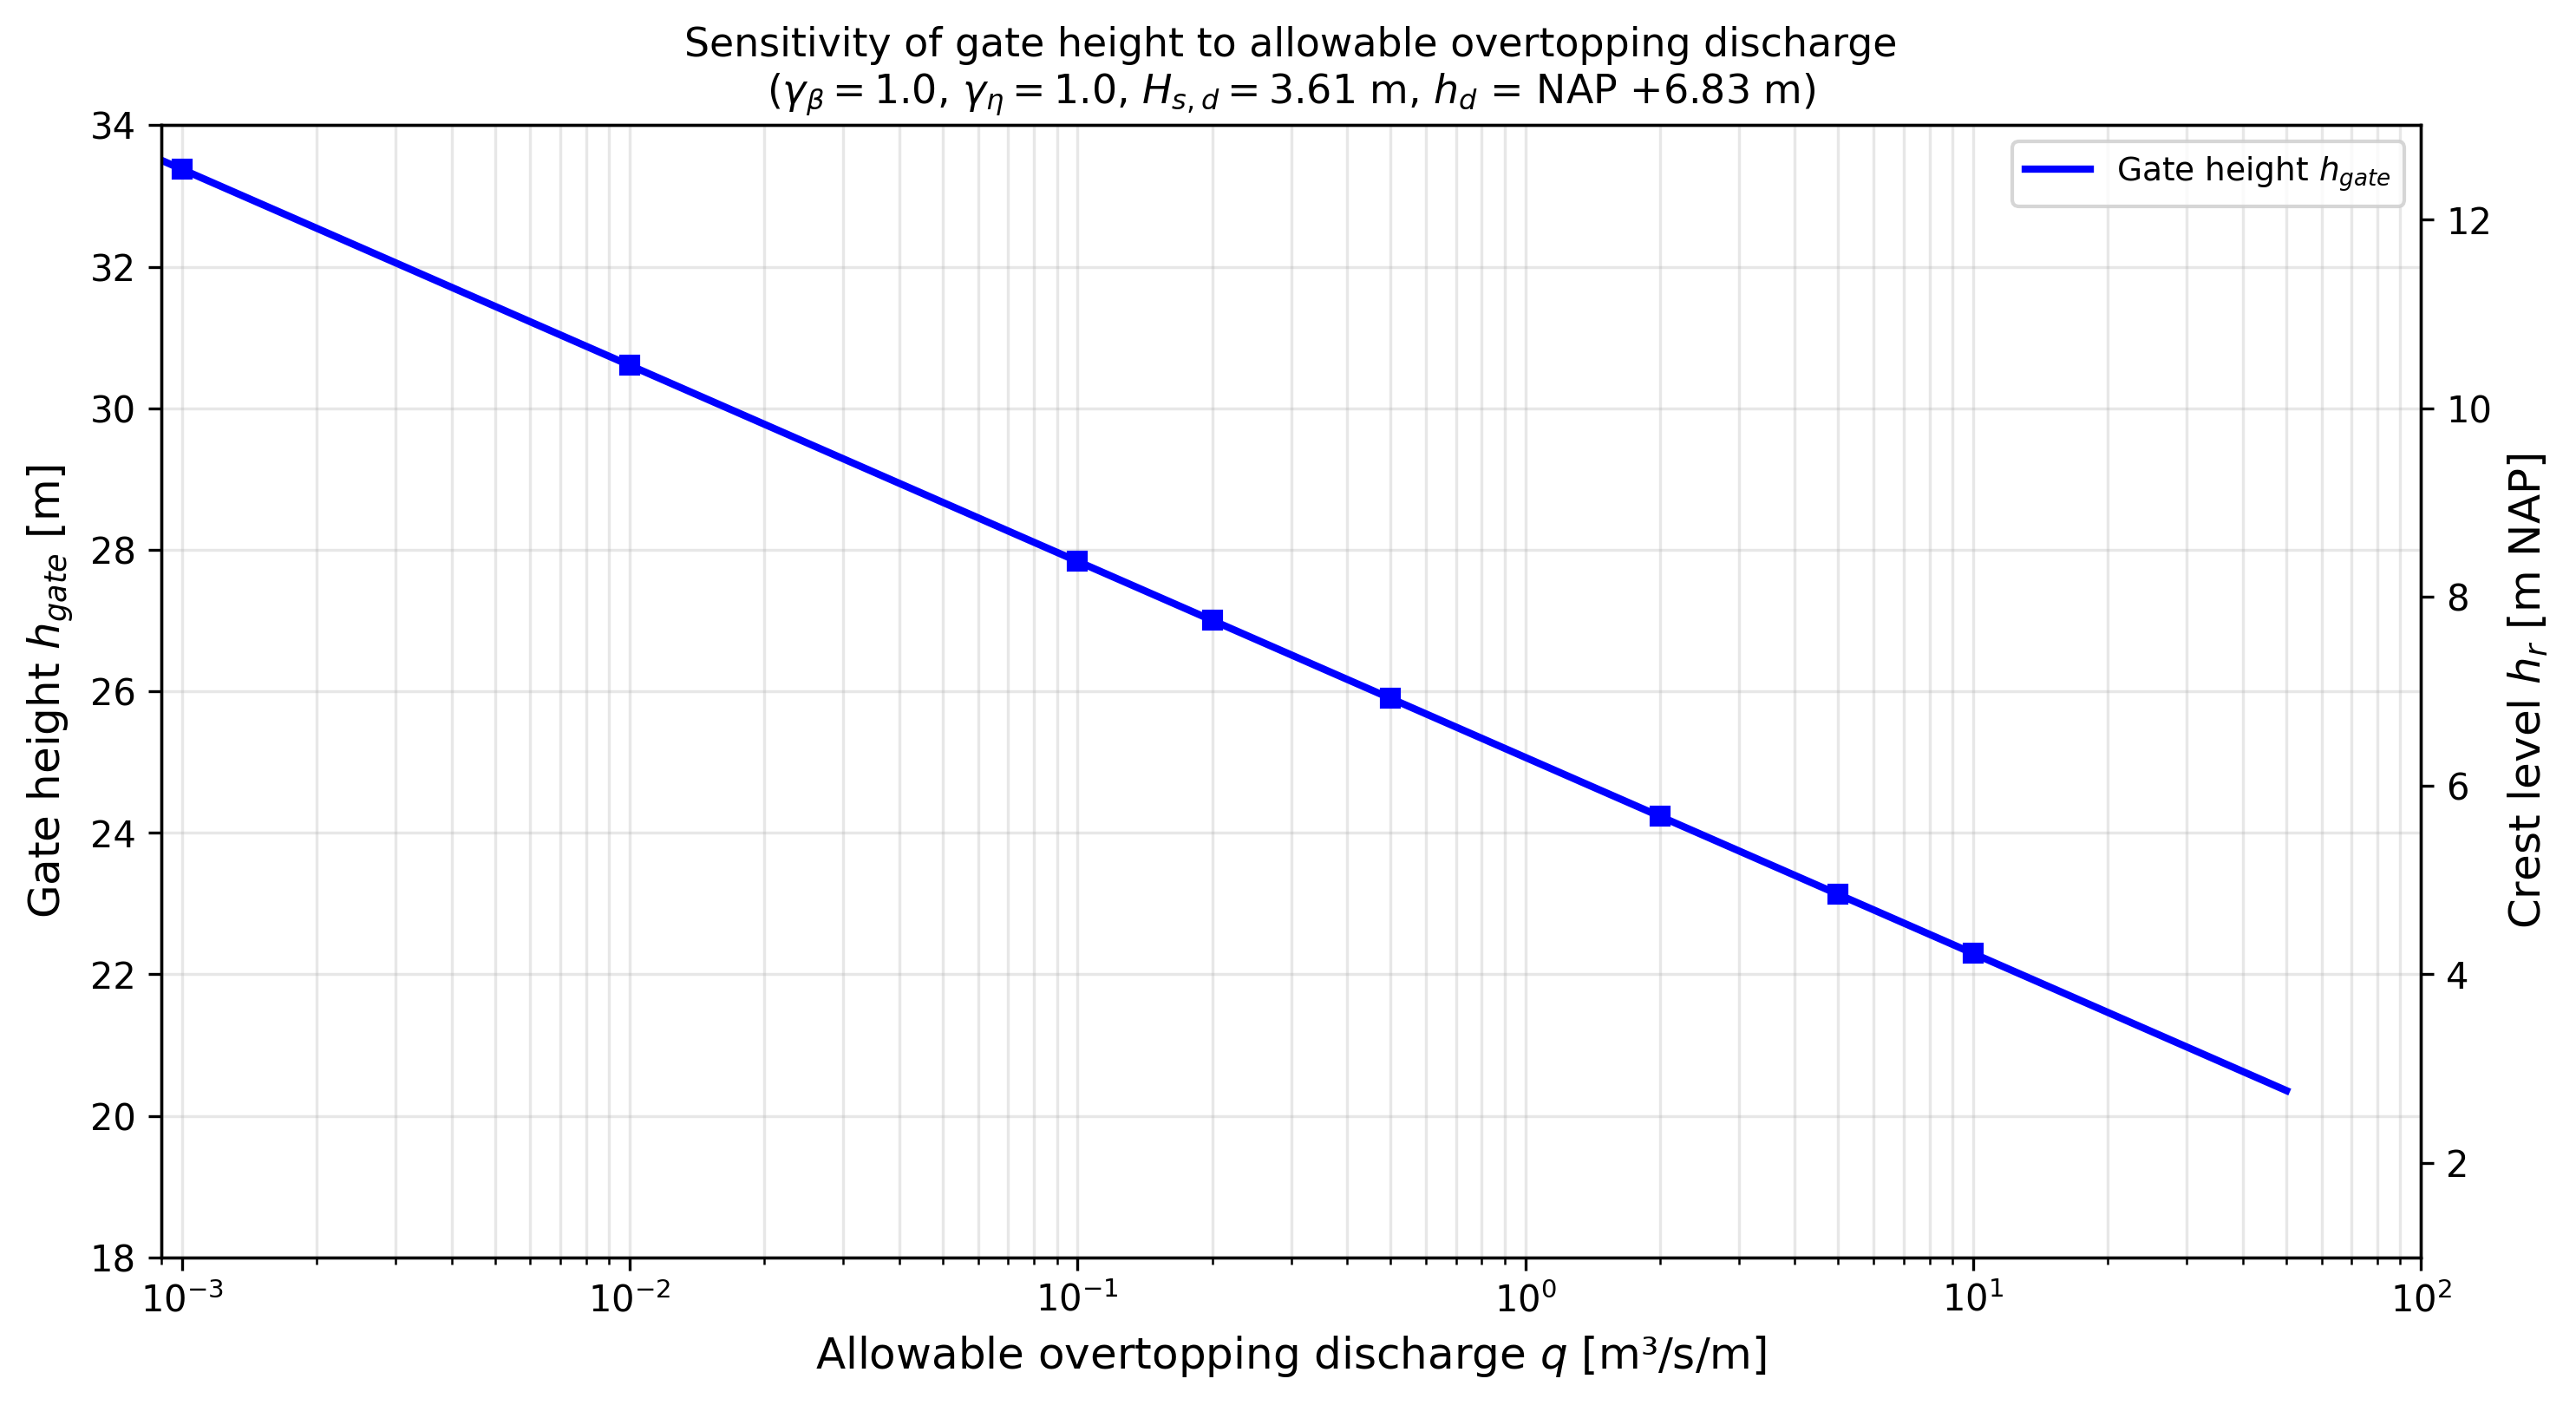

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUT PARAMETERS
# ============================================================
h_d        = 6.83     # Design water level [m NAP]
H_s_d      = 3.61     # Design significant wave height [m]
g          = 9.81     # Gravitational acceleration [m/s²]
z_sill     = -17.0    # Sill level [m NAP]
gamma_beta = 1.0      # Normal wave incidence
gamma_eta  = 1.0      # No nose structure

denom = 0.13 * np.sqrt(g * H_s_d**3)

def calc_overtopping(q_val):
    h_kr = -(1/3) * gamma_beta * gamma_eta * H_s_d * np.log(q_val / denom)
    h_r = h_d + h_kr
    h_gate = h_r - z_sill
    return h_kr, h_r, h_gate

# ============================================================
# TABLE
# ============================================================
q_values = [ 0.001, 0.01, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10]


print(f"  Design water level:       h_d     = NAP +{h_d:.2f} m")
print(f"  Significant wave height:  H_s,d   = {H_s_d:.2f} m")
print(f"  Oblique wave factor:      γ_β     = {gamma_beta:.1f}")
print(f"  Nose structure factor:    γ_η     = {gamma_eta:.1f}")
print(f"  Sill level:               z_sill  = NAP {z_sill:.1f} m")
print(f"  Gravitational accel.:     g       = {g:.2f} m/s²")
print()
print(f"  {'q [m³/s/m]':>12} | {'h_kr [m]':>9} | {'h_r [m NAP]':>12} | {'h_gate [m]':>11}")
print(f"  {'-' * 52}")

for qi in q_values:
    h_kr_i, h_r_i, h_gate_i = calc_overtopping(qi)
    print(f"  {qi:>12.3f} | {h_kr_i:>9.2f} | {h_r_i:>+12.2f} | {h_gate_i:>11.2f}")

# ============================================================
# PLOT
# ============================================================
q_plot = np.logspace(-10, 1.7, 500)
h_kr_plot = -(1/3) * gamma_beta * gamma_eta * H_s_d * np.log(q_plot / denom)
h_r_plot = h_d + h_kr_plot
h_gate_plot = h_r_plot - z_sill

# q=1 point
h_kr_1, h_r_1, h_gate_1 = calc_overtopping(1.0)

fig, ax1 = plt.subplots(figsize=(10, 5.5), dpi=300)

# Main curve
ax1.plot(q_plot, h_gate_plot, 'b-', linewidth=2.0, label='Gate height $h_{gate}$')


# Discrete points
for qi in q_values:
    h_kr_i, h_r_i, h_gate_i = calc_overtopping(qi)
    if qi != 1.0:
        ax1.plot(qi, h_gate_i, 'bs', markersize=5, zorder=4)

ax1.set_xscale('log')
ax1.set_xlabel('Allowable overtopping discharge $q$ [m³/s/m]', fontsize=12)
ax1.set_ylabel('Gate height $h_{gate}$ [m]', fontsize=12)
ax1.set_title('Sensitivity of gate height to allowable overtopping discharge\n'
              r'($\gamma_\beta = 1.0$, $\gamma_\eta = 1.0$, $H_{s,d} = 3.61$ m, '
              r'$h_d$ = NAP +6.83 m)', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, which='both', alpha=0.3)
ax1.set_xlim(0.0009, 100)
ax1.set_ylim(18, 34)

# Secondary y-axis: crest level
ax2 = ax1.twinx()
ax2.set_ylim(18 + z_sill, 30 + z_sill)
ax2.set_ylabel('Crest level $h_r$ [m NAP]', fontsize=12)

plt.tight_layout()
plt.savefig("gate_height_sensitivity_q.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
"""
Retention height and vertical design of the Holland Barrier gate
----------------------------------------------------------------
Determines the required freeboard (overtopping height), crest level and gate
height by inverting the WOWK overtopping formulation for a vertical wall.

"""

import numpy as np

# --------------------------------------------------------------------------
# INPUT PARAMETERS
# --------------------------------------------------------------------------
# Hydraulic design conditions (T = 10,000 yr, incl. +1.4 m SLR)
h_d      = 6.83      # design (outer) water level          [m NAP]
Hm0      = 3.61      # spectral significant wave height     [m]

# Geometry
z_sill   = -17.0     # sill level                           [m NAP]

# WOWK model parameters
m_os     = 0.13      # model factor for overtopping discharge [-]
g        = 9.81      # gravitational acceleration            [m/s^2]
gamma_n  = 1.0       # influence factor nose structure       [-]  (no nose structure)
gamma_b  = 1.0       # influence factor oblique waves        [-]  (beta ~ 0 deg)

# Allowable mean overtopping discharge
q        = 0.100     # design allowable discharge            [m^3/s/m]  (= 100 l/s/m)

# Barrier width (for total inflow check)
B_gate   = 360.0     # total width between abutments         [m]

# --------------------------------------------------------------------------
# CALCULATION
# --------------------------------------------------------------------------
# Required freeboard h_kr = h_r - h_d  (Eq. overtopping_height)
h_kr = -(gamma_n * gamma_b * Hm0 / 3.0) * np.log(q / (m_os * np.sqrt(g * Hm0**3)))

# Crest level (Eq. retention_height)
h_r = h_d + h_kr

# Gate height (Eq. gate_height)
h_gate = h_r - z_sill

# Total inflow into the intermediate basin at the design discharge
Q_total = q * B_gate

# --------------------------------------------------------------------------
# OUTPUT
# --------------------------------------------------------------------------
print("=" * 55)
print(" Retention height and vertical design - Holland Barrier")
print("=" * 55)
print(f" Design water level      h_d      = {h_d:+6.2f} m NAP")
print(f" Significant wave height Hm0      = {Hm0:6.2f} m")
print(f" Allowable discharge     q        = {q*1000:6.0f} l/s/m")
print("-" * 55)
print(f" Overtopping height      h_kr     = {h_kr:+6.2f} m")
print(f" Crest level             h_r      = {h_r:+6.2f} m NAP")
print(f" Sill level              z_sill   = {z_sill:+6.2f} m NAP")
print(f" Gate height             h_gate   = {h_gate:6.2f} m")
print("-" * 55)
print(f" Total inflow (q x {B_gate:.0f} m)  Q_total  = {Q_total:6.1f} m^3/s")
print("=" * 55)


 Retention height and vertical design - Holland Barrier
 Design water level      h_d      =  +6.83 m NAP
 Significant wave height Hm0      =   3.61 m
 Allowable discharge     q        =    100 l/s/m
-------------------------------------------------------
 Overtopping height      h_kr     =  +4.01 m
 Crest level             h_r      = +10.84 m NAP
 Sill level              z_sill   = -17.00 m NAP
 Gate height             h_gate   =  27.84 m
-------------------------------------------------------
 Total inflow (q x 360 m)  Q_total  =   36.0 m^3/s


***Vessel calculation***

In [2]:
import pandas as pd

# ==========================================================
# INPUT DATA
# ==========================================================

vessels = {
    "New Panamax": {"L": 366, "B": 48.4, "T": 15.0},
    "Panamax": {"L": 294, "B": 32.3, "T": 12.0},
    "Aframax Tanker": {"L": 244, "B": 42.0, "T": 13.4},
    "Handymax": {"L": 200, "B": 32.0, "T": 11.5},
}

# Geometry Holland Barrier
NAV_WIDTH = 318.0          # navigable width [m]
ABUTMENT_WIDTH = 360.0     # distance between abutments [m]
SILL_LEVEL = -17.0         # NAP [m]

# DHMR parameters
LAT = -0.90                # [m NAP]
HMT = 0.30                 # [m]
FWA_PERC = 0.01            # 1 %
UKC_PERC = 0.10            # 10 %

# ==========================================================
# HORIZONTAL VERIFICATION
# X = 2B + 70
# ==========================================================

horizontal_results = []

for name, data in vessels.items():

    B = data["B"]

    X = 2 * B + 70

    horizontal_results.append({
        "Vessel": name,
        "Beam B [m]": B,
        "Required width X [m]": round(X, 1),
        "≤ 318 m": X <= NAV_WIDTH,
        "≤ 360 m": X <= ABUTMENT_WIDTH
    })

horizontal_df = pd.DataFrame(horizontal_results)

print("\nONE-WAY NAVIGATION WIDTH")
print(horizontal_df)


# ==========================================================
# TWO-WAY TRAFFIC
# X_total = X1 + X2
# ==========================================================

def width_requirement(B):
    return 2 * B + 70


combinations = [
    ("New Panamax", "New Panamax"),
    ("Aframax Tanker", "Aframax Tanker"),
    ("New Panamax", "Panamax"),
    ("Aframax Tanker", "Panamax"),
    ("Panamax", "Panamax"),
]

twoway_results = []

for v1, v2 in combinations:

    X1 = width_requirement(vessels[v1]["B"])
    X2 = width_requirement(vessels[v2]["B"])

    X_total = X1 + X2

    twoway_results.append({
        "Combination": f"{v1} + {v2}",
        "X_total [m]": round(X_total, 1),
        "≤ 318 m": X_total <= NAV_WIDTH,
        "≤ 360 m": X_total <= ABUTMENT_WIDTH
    })

twoway_df = pd.DataFrame(twoway_results)

print("\nTWO-WAY NAVIGATION WIDTH")
print(twoway_df)


# ==========================================================
# VERTICAL VERIFICATION
# NGD = -T - FWA*T - UKC*T + LAT - HMT
# ==========================================================

vertical_results = []

for name, data in vessels.items():

    T = data["T"]

    FWA = FWA_PERC * T
    UKC = UKC_PERC * T

    NGD = -T - FWA - UKC + LAT - HMT

    vertical_results.append({
        "Vessel": name,
        "Draft T [m]": T,
        "NGD [m NAP]": round(NGD, 2),
        "|NGD| ≤ 17.0": abs(NGD) <= abs(SILL_LEVEL)
    })

vertical_df = pd.DataFrame(vertical_results)

print("\nVERTICAL VERIFICATION")
print(vertical_df)


# ==========================================================
# TIDE-BOUND CHECK
# h_w,min = z_sill + T + FWA + UKC + HMT
# ==========================================================

print("\nMINIMUM WATER LEVEL REQUIRED")

for name, data in vessels.items():

    T = data["T"]

    FWA = FWA_PERC * T
    UKC = UKC_PERC * T

    h_w_min = (
        SILL_LEVEL
        + T
        + FWA
        + UKC
        + HMT
    )

    print(
        f"{name:20s} "
        f"h_w,min = NAP {h_w_min:.2f} m"
    )



ONE-WAY NAVIGATION WIDTH
           Vessel  Beam B [m]  Required width X [m]  ≤ 318 m  ≤ 360 m
0     New Panamax        48.4                 166.8     True     True
1         Panamax        32.3                 134.6     True     True
2  Aframax Tanker        42.0                 154.0     True     True
3        Handymax        32.0                 134.0     True     True

TWO-WAY NAVIGATION WIDTH
                       Combination  X_total [m]  ≤ 318 m  ≤ 360 m
0        New Panamax + New Panamax        333.6    False     True
1  Aframax Tanker + Aframax Tanker        308.0     True     True
2            New Panamax + Panamax        301.4     True     True
3         Aframax Tanker + Panamax        288.6     True     True
4                Panamax + Panamax        269.2     True     True

VERTICAL VERIFICATION
           Vessel  Draft T [m]  NGD [m NAP]  |NGD| ≤ 17.0
0     New Panamax         15.0       -17.85         False
1         Panamax         12.0       -14.52          True
2  Af